In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js

In [ ]:
def take_photo(filename='webcam_photo.jpg', quality=0.85):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      video.style.display = 'block';
      const modelOut = document.createElement('div');
      button.textContent = 'Take a photo';
      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => button.onclick = () => resolve()); // Corrected event listener

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0)
      stream.getVideoTracks()[0].stop(); // Corrected typo
      div.remove();
      return canvas.toDataURL('image/jpeg', quality)
    }
    ''')

  display(js)
  data = eval_js(f'takePhoto({quality})')
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

In [ ]:
photo_path = take_photo()
frame = cv2.imread(photo_path)

if frame is None:
  raise ValueError('Could Not Read Webcam Image')

print('Captured image:', photo_path)
print('Frame shape:', frame.shape)

<IPython.core.display.Javascript object>

Captured image: webcam_photo.jpg
Frame shape: (480, 640, 3)


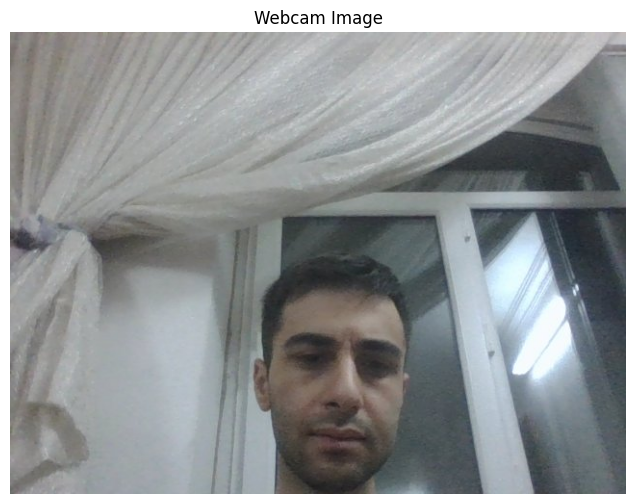

In [ ]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title('Webcam Image')
plt.axis('off')

plt.show()

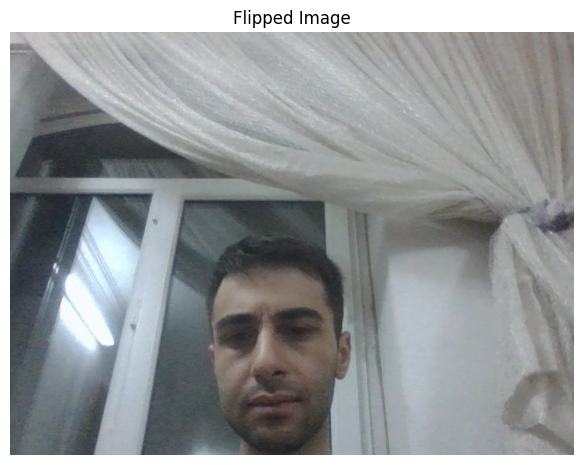

In [ ]:
flipped = cv2.flip(frame, 1)

plt.figure(figsize=(16, 6))
plt.subplot(121)
plt.imshow(flipped[..., ::-1])
plt.title('Flipped Image')
plt.axis('off')

plt.show()

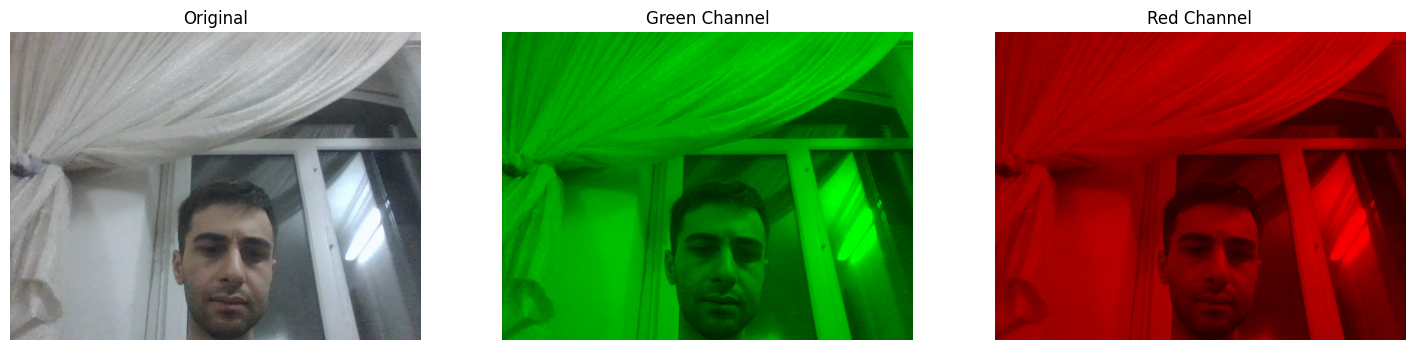

In [ ]:
height, width, _ = frame.shape
zeros = np.zeros((height, width), dtype=np.uint8)
b_ch, g_ch, r_ch = cv2.split(frame)

image_green = cv2.merge([zeros, g_ch, zeros])
image_red = cv2.merge([zeros, zeros, r_ch])

plt.figure(figsize=(18, 6))
plt.subplot(131)
plt.imshow(frame[..., ::-1])
plt.title('Original')
plt.axis('off')

plt.subplot(132)
plt.imshow(image_green[..., ::-1])
plt.title('Green Channel')
plt.axis('off')

plt.subplot(133)
plt.imshow(image_red[..., ::-1])
plt.title('Red Channel')
plt.axis('off')

plt.show()

<IPython.core.display.Javascript object>

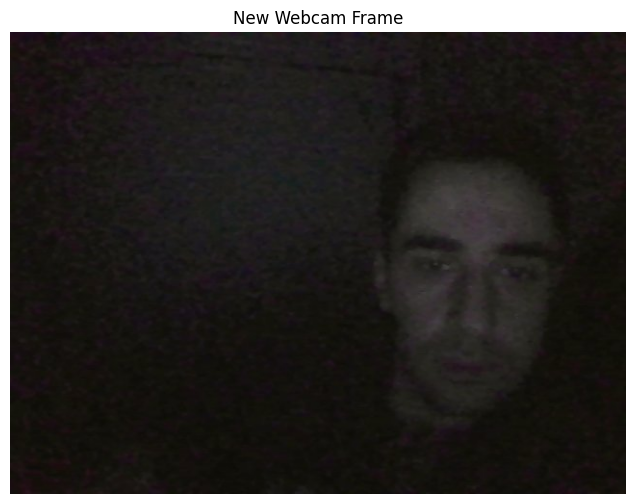

In [ ]:
photo_path_2 = take_photo('webcam_photo_2.jpg')
frame_2 = cv2.imread(photo_path_2)

if frame_2 is None:
    raise ValueError('Could Not Read Webcam Image')

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame_2, cv2.COLOR_BGR2RGB))
plt.title('New Webcam Frame')
plt.axis('off')

plt.show()